# PV power and the Typical Meteorological Year (live)

Beyond raw radiation, PVGIS can model **PV system power** and synthesise a
**Typical Meteorological Year (TMY)**. This notebook switches on PV modelling
for `seriescalc` and pulls a TMY for the same point.

In [1]:
import tempfile

import matplotlib.pyplot as plt
from earthlens.earthlens import EarthLens

OUT = tempfile.mkdtemp()

## PV system power with `pvcalculation=1`

The PV knobs ride through to the PVGIS query: `pvcalculation=1` turns on the
model, `peakpower` (kWp), `loss` (%), `angle` (tilt °), and `aspect` (azimuth °,
0 = south) describe the array. The result gains a `P` column — PV power in W.

In [2]:
pv = EarthLens(
    data_source="pvgis",
    variables=["seriescalc"],
    start="2020-01-01",
    end="2020-12-31",
    point=(45.0, 8.0),
    pvcalculation=1,
    peakpower=1,
    loss=14,
    angle=35,
    aspect=0,
    path=OUT,
).download(progress_bar=False)

print("P" in pv.columns, pv["P"].max(), "W peak")
pv[["time", "P", "G(i)"]].head()

2026-06-26 20:45:09.432 | INFO     | earthlens.pvgis.backend:download:327 - PVGIS seriescalc: 8784 row(s) -> C:\Users\main\AppData\Local\Temp\tmpsrtrg09x\pvgis_seriescalc.csv


2026-06-26 20:45:09.433 | INFO     | earthlens.pvgis.backend:download:328 - PVGIS (c) European Union, 2001-2024 — data from the JRC Photovoltaic Geographical Information System (PVGIS), https://re.jrc.ec.europa.eu/pvg_tools/. Free reuse with attribution.


True 836.06 W peak


,time,P,G(i)
0,2020-01-01 00:10:00,0.0,0.0
1,2020-01-01 01:10:00,0.0,0.0
2,2020-01-01 02:10:00,0.0,0.0
3,2020-01-01 03:10:00,0.0,0.0
4,2020-01-01 04:10:00,0.0,0.0


A representative summer day shows the modelled PV power profile.

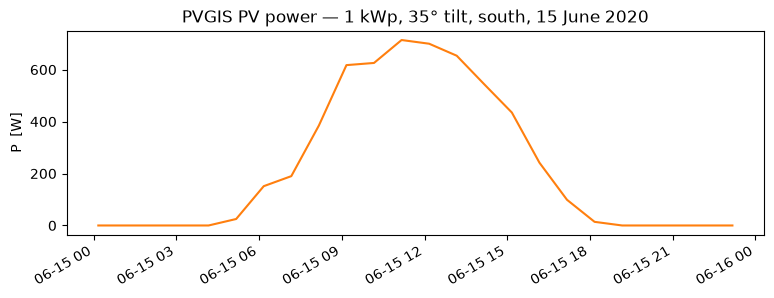

In [3]:
day = pv[(pv["time"] >= "2020-06-15") & (pv["time"] < "2020-06-16")]

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(day["time"], day["P"], color="tab:orange")
ax.set_ylabel("P  [W]")
ax.set_title("PVGIS PV power — 1 kWp, 35° tilt, south, 15 June 2020")
fig.autofmt_xdate()
plt.show()

## A Typical Meteorological Year

`variables=["tmy"]` returns one synthetic 8760-hour year of meteorological
variables (temperature, humidity, irradiance components, wind, pressure) — no
year window needed.

In [4]:
tmy = EarthLens(
    data_source="pvgis",
    variables=["tmy"],
    start="2020-01-01",
    end="2020-12-31",
    point=(45.0, 8.0),
    path=OUT,
).download(progress_bar=False)

print(tmy.shape)
tmy[["time", "T2m", "RH", "G(h)"]].head()

2026-06-26 20:45:11.263 | INFO     | earthlens.pvgis.backend:download:327 - PVGIS tmy: 8760 row(s) -> C:\Users\main\AppData\Local\Temp\tmpsrtrg09x\pvgis_tmy.csv


2026-06-26 20:45:11.264 | INFO     | earthlens.pvgis.backend:download:328 - PVGIS (c) European Union, 2001-2024 — data from the JRC Photovoltaic Geographical Information System (PVGIS), https://re.jrc.ec.europa.eu/pvg_tools/. Free reuse with attribution.


(8760, 13)


,time,T2m,RH,G(h)
0,2018-01-01 00:00:00,2.04,94.38,0.0
1,2018-01-01 01:00:00,1.98,95.45,0.0
2,2018-01-01 02:00:00,1.92,96.51,0.0
3,2018-01-01 03:00:00,1.85,97.57,0.0
4,2018-01-01 04:00:00,1.79,98.64,0.0


## Takeaway

The same `download()` shape gives raw radiation, modelled PV power (with the PV
knobs), or a TMY — selected entirely by `variables=` and the keyword knobs. All
keyless, all returned as tidy hourly `DataFrame`s.